<a href="https://colab.research.google.com/github/MRazaRashid/SolvedMLNotebooks/blob/main/Task_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Task` How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.

Note : Use KNN for Classification.

Data Link :  [Wine Data](https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv)

In [ ]:
# Data Loading
import pandas as pd
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
df = pd.read_csv(wine_data_path)
df.sample(6)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
2622,white,6.6,0.26,0.21,2.9,0.026,48.0,126.0,0.99089,3.22,0.38,11.3,7
3424,white,6.4,0.32,0.27,4.9,0.034,18.0,122.0,0.99160,3.36,0.71,12.5,6
3626,white,7.0,0.29,0.33,0.9,0.041,20.0,117.0,0.99048,3.21,0.50,11.4,5
3447,white,6.0,0.17,0.29,9.7,0.044,33.0,98.0,0.99536,3.12,0.36,9.2,6
4887,white,6.2,0.41,0.22,1.9,0.023,5.0,56.0,0.98928,3.04,0.79,13.0,7
1016,white,6.8,0.37,0.47,11.2,0.071,44.0,136.0,0.99680,2.98,0.88,9.2,5


In [ ]:
# Your Code goes Here
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
df.shape

(6463, 13)

In [ ]:
df.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [ ]:
df = df.dropna()

In [ ]:
X = df.drop(columns=["type", "quality"])
y = df["type"].map({"red": 0, "white": 1})   # text labels -> 0/1

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only
X_test_s = scaler.transform(X_test)

In [ ]:
K = 5

def run_knn(Xtr, Xte, label):
    knn = KNeighborsClassifier(n_neighbors=K)
    t0 = time.perf_counter()
    knn.fit(Xtr, y_train)
    pred = knn.predict(Xte)
    elapsed = time.perf_counter() - t0
    acc = accuracy_score(y_test, pred)
    print(f"{label:<28} features={Xtr.shape[1]:<3} accuracy={acc:.4f} time={elapsed:.4f}s")
    return acc, elapsed, pred

In [ ]:
acc_base, time_base, pred_base = run_knn(X_train_s, X_test_s, "KNN (no PCA)")

KNN (no PCA)                 features=11  accuracy=0.9946 time=0.0910s


In [ ]:
pca_full = PCA().fit(X_train_s)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.argmax(cum_var >= 0.90) + 1)
print(f"\nComponents needed for 95% variance: {n_95} of {X_train_s.shape[1]}")


Components needed for 95% variance: 8 of 11


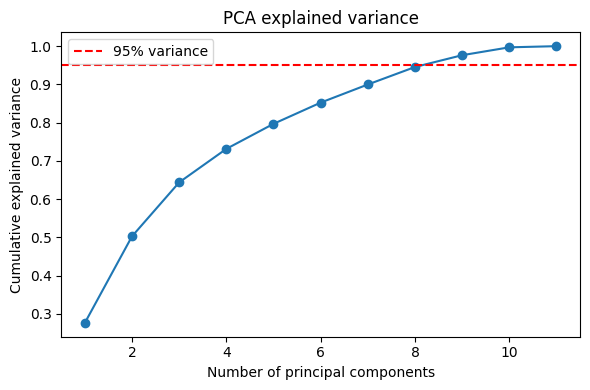

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.95, color="r", linestyle="--", label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.legend()
plt.tight_layout()
plt.savefig("pca_explained_variance.png", dpi=150)

In [ ]:
pca = PCA(n_components=n_95).fit(X_train_s)
X_train_p = pca.transform(X_train_s)
X_test_p = pca.transform(X_test_s)
print()
acc_pca, time_pca, pred_pca = run_knn(X_train_p, X_test_p, f"KNN + PCA ({n_95} comps)")


KNN + PCA (8 comps)          features=8   accuracy=0.9915 time=0.0821s
